In [30]:
from shapely.geometry import Polygon
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors

In [15]:

use_all_of_trondheim = False
remove_bridge = False
place_name = "Trondheim, Norway"

Define a polygon (Example: central Trondheim area)

In [16]:
polygon = Polygon([
    (10.35, 63.41),  # Southwest corner
    (10.42, 63.41),  # Southeast
    (10.42, 63.44),  # Northeast
    (10.35, 63.44),  # Northwest
])


TRUE: use_all_of_trondheim is true, use the whole area of Trondheim

FALSE: use_all_of_trondheim is false, use the polygon defined above which is the central area of Trondheim

In [17]:
if use_all_of_trondheim:
    G = ox.graph_from_place(place_name, network_type='drive', simplify=True)
else:
    G = ox.graph_from_polygon(polygon, network_type='drive', simplify=True)

If remove bridge is true Remove Elgeseter Bridge from the map

In [19]:
if remove_bridge:
    north_end_coords = (10.3955, 63.4284)  # Midtbyen side
    south_end_coords = (10.3965, 63.4261)  # Elgeseter side

    # Find the nearest nodes in the graph
    north_node = 3051860254 
    south_node = 54465660
    
    print(f"North End Node: {north_node}")
    print(f"South End Node: {south_node}")

    # Find all edges along the bridge
    edges_to_remove = []
    for u, v, key in G.edges(keys=True):
        if (u == north_node or v == north_node) or (u == south_node or v == south_node):
            edges_to_remove.append((u, v, key))

    # Remove edges
    for edge in edges_to_remove:
        try:
            G.remove_edge(*edge)
            print(f"Removed edge: {edge}")
        except Exception as e:
            print(f"Could not remove edge {edge}: {e}")

In [20]:
G_undirected = nx.Graph(G)

Betweeness Centrality

In [38]:
# Calculate centrality measures
node_centrality = nx.betweenness_centrality(G_undirected)
# Get the top 5 nodes by centrality
top_nodes = sorted(node_centrality.items(), key=lambda x: x[1], reverse=True)[:5]
# Color the nodes according to their centrality
node_color = [node_centrality.get(node, 0) for node in G.nodes()]

edge_centrality = nx.edge_betweenness_centrality(G_undirected, normalized=True)

# Get the top 5 edges by centrality
top_edges = sorted(edge_centrality.items(), key=lambda x: x[1], reverse=True)[:5]

print("Top 5 edges by centrality:")
for edge, centrality in top_edges:
    print(f"{edge}: {centrality}")

Top 5 edges by centrality:
(105366, 5839056923): 0.25730399126492925
(60122692, 4424333594): 0.2115007244860766
(500696864, 4424333594): 0.2113893251777499
(78271, 78309): 0.20584164899083873
(105366, 5839056963): 0.2051442955822881


In [ ]:
# Min-max scaling
min_bc = min(edge_centrality.values())
max_bc = max(edge_centrality.values())
 
# Avoid division by zero if all values are the same
if max_bc - min_bc > 0:
    scaled_edge_centrality = {
        edge: (bc - min_bc) / (max_bc - min_bc) for edge, bc in edge_centrality.items()
    }
else:
    scaled_edge_centrality = {edge: 0 for edge in edge_centrality}  # If all are the same, set to 0

top_edges = sorted(scaled_edge_centrality.items(), key=lambda x: x[1], reverse=True)[:5]
bottom_edges = sorted(scaled_edge_centrality.items(), key=lambda x: x[1], reverse=False)[:5]

print("Top 5 edges by centrality:")
for edge, centrality in top_edges:
    print(f"{edge}: {centrality}")
    
print("Bottom 5 edges by centrality:")
for edge, centrality in bottom_edges:
    print(f"{edge}: {centrality}")

Top 5 edges by centrality:
(105366, 5839056923): 1.0
(60122692, 4424333594): 0.8219877330558312
(500696864, 4424333594): 0.8215547848229684
(78271, 78309): 0.7999939992337581
(105366, 5839056963): 0.7972837676313551
Bottom 5 edges by centrality:
(33847913, 33847913): 0.0
(245005789, 245005789): 0.0
(267446585, 267446585): 0.0
(1203329991, 1203329991): 0.0
(4304873407, 4304873407): 0.0


KeyError: (78260, 78257)

Plot Figure

IndexError: indices are out-of-bounds

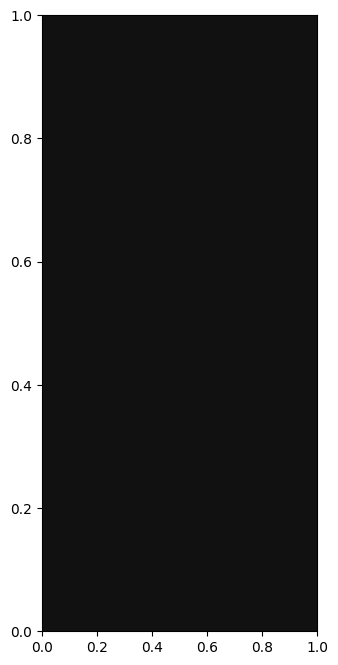

In [ ]:
fig, ax = ox.plot_graph(
    G, 
    node_color=node_color,
    node_size=10,
    edge_linewidth=1
)